#**Extreme Gradient Boosting Classifier**

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split,cross_val_score
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score,accuracy_score,roc_curve,auc
from sklearn.model_selection import KFold

**Reading Dataset from drive**

In [ ]:
columns = ["ID", "Diagnosis", "radius1", "texture1", "perimeter1", "area1", "smoothness1", "compactness1", "concavity1", "concave_points1", "symmetry1", "fractal_dimension1", "radius2", "texture2", "perimeter2", "area2", "smoothness2", "compactness2", "concavity2", "concave_points2", "symmetry2", "fractal_dimension2", "radius3", "texture3", "perimeter3", "area3", "smoothness3", "compactness3", "concavity3", "concave_points3", "symmetry3", "fractal_dimension3"]

data = pd.read_csv('/content/drive/My Drive/Sem5/new_ml/a4/wdbc.data',header = None, names = columns)
target_col = "Diagnosis"

In [ ]:
data.head()

,ID,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


#**EDA**

**(i) Missing values**

In [ ]:
data.isnull().sum()

,0
ID,0
Diagnosis,0
radius1,0
texture1,0
perimeter1,0
area1,0
smoothness1,0
compactness1,0
concavity1,0
concave_points1,0


**(ii) Handle Outliers**

In [ ]:
'''for col in data.columns:
  sns.boxplot(data[[col]])
  plt.tight_layout()
  plt.show()'''

'for col in data.columns:\n  sns.boxplot(data[[col]])\n  plt.tight_layout()\n  plt.show()'

In [ ]:
x = data.loc[:,data.columns!=target_col]
y = data.iloc[:,data.columns==target_col]

**(iv) Label encoding**

In [ ]:
def double(val):
  if val == 'M':
    return 1

  return 0

y = pd.Series(list(map(double, list(y['Diagnosis']))))
#print(y)

In [ ]:
x

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
'''for col in x.columns:
  Q1 = x[col].quantile(0.25)
  Q3 = x[col].quantile(0.75)
  IQR = Q3 - Q1
  low = Q1 - 1.5 * IQR
  high = Q3 + 1.5 * IQR

  x[col] = x[col].clip(low, high)'''

'for col in x.columns:\n  Q1 = x[col].quantile(0.25)\n  Q3 = x[col].quantile(0.75)\n  IQR = Q3 - Q1\n  low = Q1 - 1.5 * IQR\n  high = Q3 + 1.5 * IQR\n\n  x[col] = x[col].clip(low, high)'

In [ ]:
'''for col in x.columns:
  sns.boxplot(col)
  plt.tight_layout()
  plt.show()'''

'for col in x.columns:\n  sns.boxplot(col)\n  plt.tight_layout()\n  plt.show()'

**(iii) Standarization / Normalization**

In [ ]:
x.head()

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
x_standard = x.copy()
standard = StandardScaler()

for col in x_standard.columns[1:]:
  x_standard[col] = standard.fit_transform(x_standard[[col]])

x_standard.head()

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,842302,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,842517,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,84300903,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,84348301,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,84358402,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [ ]:
x_norm = x.copy()
normalize = MinMaxScaler()

for col in x_norm.columns[1:]:
  x_norm[col] = normalize.fit_transform(x_norm[[col]])

x_norm.head()

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,842302,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,842517,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,84300903,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,84348301,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,84358402,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595


#**Feature Engineering**

#**Splitting**

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x_norm,y,test_size=0.5,random_state = 42)
x_val,x_test,y_val,y_test = train_test_split(x_test,y_test,test_size=0.2,random_state = 42)

In [ ]:
print(x_train.shape,y_train.shape)

(284, 31) (284,)


In [ ]:
print(x_val.shape,y_val.shape)
print(x_test.shape,y_test.shape)

(228, 31) (228,)
(57, 31) (57,)


#**Model Building**

#**Extreme Gradient Boosting Classifier**

In [ ]:
model = XGBClassifier()
model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

Accuracy Score of Training  : 1.0
Precision Score of Training : 1.0
F1 Score of Training        : 1.0
Recall Score of Training    : 1.0

Confusion Matrix :- 
 [[170   0]
 [  0 114]]


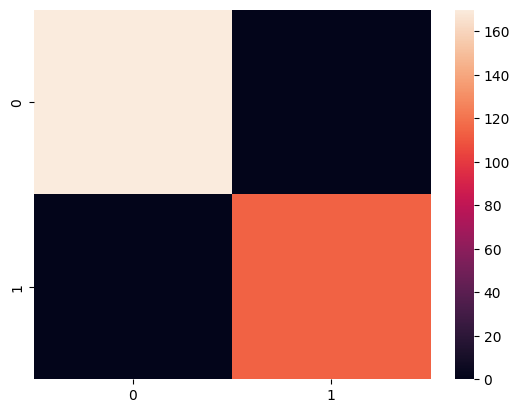

In [ ]:
y_pre_train = model.predict(x_train)
con_train_model = confusion_matrix(y_train,y_pre_train)
sns.heatmap(con_train_model)

accuracy_model_train = accuracy_score(y_train,y_pre_train)
precision_model_train = precision_score(y_train,y_pre_train)
f1_model_train = f1_score(y_train,y_pre_train)
recall_model_train = recall_score(y_train,y_pre_train)

print("Accuracy Score of Training  :",accuracy_model_train)
print("Precision Score of Training :",precision_model_train)
print("F1 Score of Training        :",f1_model_train)
print("Recall Score of Training    :",recall_model_train)
print("\nConfusion Matrix :- \n",con_train_model)


**Parameters of the Model**

In [ ]:
model.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

#**Grid Search CV**

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300, 500, 1000],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],
    'max_depth' : [2,3,4,5],
    'gamma' : [0, 0.1, 0.5, 1, 5],
    'subsample': [0.6,0.8,1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
}


grid = GridSearchCV(model,param_grid = param_grid, cv = 5)
grid.fit(x_val,y_val)
print(grid.best_params_)
print(grid.best_score_)

#{'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.6}
#0.9824154589371981

{'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.6}
0.9824154589371981


#**Randomized Search CV**

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300, 500, 1000],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],
    'max_depth' : [2,3,4,5],
    'gamma' : [0, 0.1, 0.5, 1, 5],
    'subsample': [0.6,0.8,1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
}


randomsearch = RandomizedSearchCV(model,param_distributions = param_grid, n_iter=10, cv = 5)
randomsearch.fit(x_val,y_val)
print(randomsearch.best_params_)
print(randomsearch.best_score_)

#{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 2, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.7}
#0.9693719806763286

{'subsample': 0.6, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.9}
0.9649275362318841


**Model with Fine Tuned Hyper Parameters**

In [ ]:
model = XGBClassifier(colsample_bytree = 0.6, gamma = 0, learning_rate = 0.2, max_depth = 3, n_estimators = 200, subsample = 0.6)
model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

#**Testing**


Accuracy Score of Testing  : 0.9824561403508771
Precision Score of Testing : 0.9375
F1 Score of Testing        : 0.967741935483871
Recall Score of Testing    : 1.0

Confusion Matrix :- 
 [[170   0]
 [  0 114]]


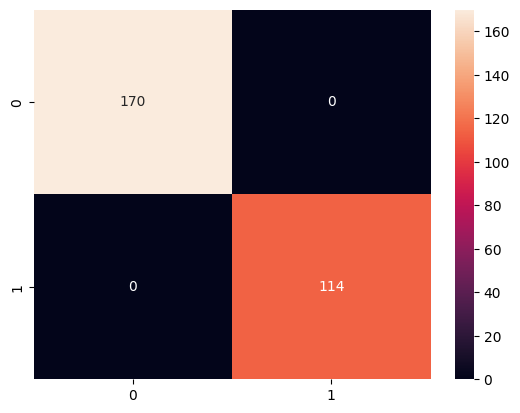

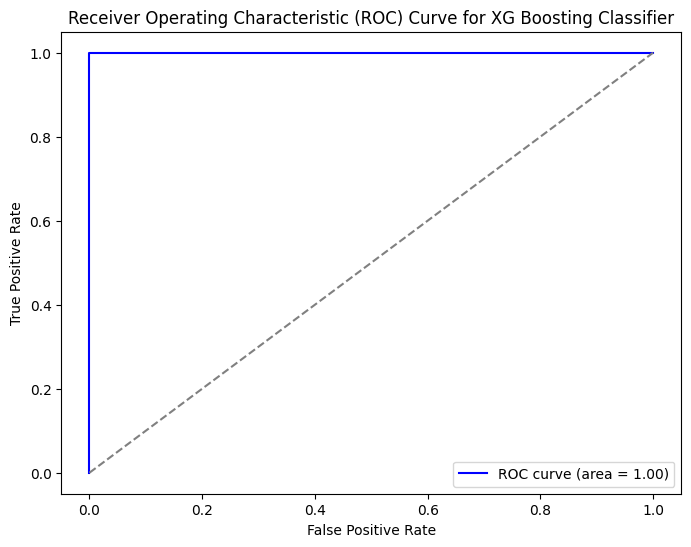

In [ ]:
y_pre_test = model.predict(x_test)
con_test_model = confusion_matrix(y_train,y_pre_train)
sns.heatmap(con_test_model,annot=True,fmt='d')

accuracy_model_test = accuracy_score(y_test,y_pre_test)
precision_model_test = precision_score(y_test,y_pre_test)
f1_model_test = f1_score(y_test,y_pre_test)
recall_model_test = recall_score(y_test,y_pre_test)

print("\nAccuracy Score of Testing  :",accuracy_model_test)
print("Precision Score of Testing :",precision_model_test)
print("F1 Score of Testing        :",f1_model_test)
print("Recall Score of Testing    :",recall_model_test)
print("\nConfusion Matrix :- \n",con_test_model)

y_probs_knn = model.predict_proba(x_test)[:, 1]
fpr_model, tpr_model, thresholds = roc_curve(y_test, y_probs_knn)
roc_auc_model = auc(fpr_model, tpr_model)

plt.figure(figsize=(8, 6))
plt.plot(fpr_model, tpr_model, color='b', label=f'ROC curve (area = {roc_auc_model:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve for XG Boosting Classifier')
plt.legend(loc='lower right')
plt.show()

#**Cross validation**


----- Fold ------
Accuracy Score of Training  : 1.0
Precision Score of Training : 1.0
F1 Score of Training        : 1.0
Recall Score of Training    : 1.0

Confusion Matrix :- 
 [[286   0]
 [  0 169]]

Accuracy Score of Testing  : 0.9736842105263158
Precision Score of Testing : 1.0
F1 Score of Testing        : 0.963855421686747
Recall Score of Testing    : 0.9302325581395349

Confusion Matrix :- 
 [[286   0]
 [  0 169]]


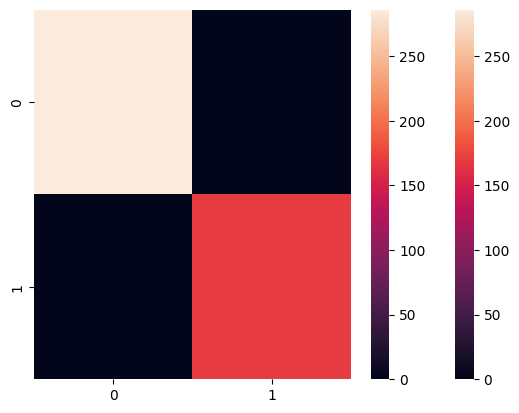

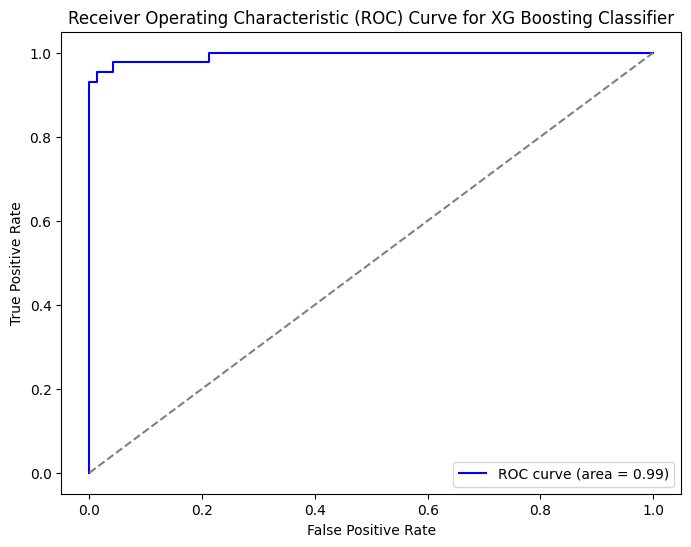


----- Fold ------
Accuracy Score of Training  : 1.0
Precision Score of Training : 1.0
F1 Score of Training        : 1.0
Recall Score of Training    : 1.0

Confusion Matrix :- 
 [[280   0]
 [  0 175]]

Accuracy Score of Testing  : 0.9824561403508771
Precision Score of Testing : 0.972972972972973
F1 Score of Testing        : 0.972972972972973
Recall Score of Testing    : 0.972972972972973

Confusion Matrix :- 
 [[280   0]
 [  0 175]]


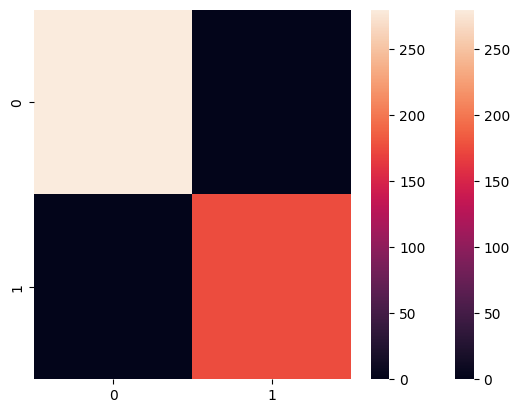

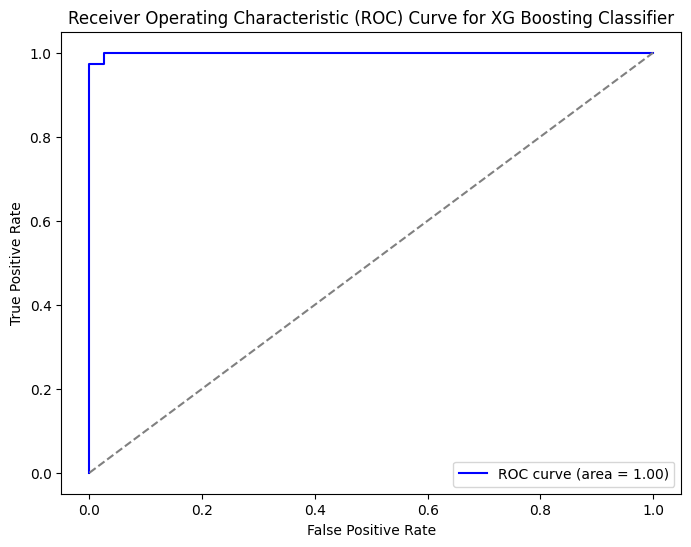


----- Fold ------
Accuracy Score of Training  : 1.0
Precision Score of Training : 1.0
F1 Score of Training        : 1.0
Recall Score of Training    : 1.0

Confusion Matrix :- 
 [[286   0]
 [  0 169]]

Accuracy Score of Testing  : 0.9385964912280702
Precision Score of Testing : 0.9285714285714286
F1 Score of Testing        : 0.9176470588235294
Recall Score of Testing    : 0.9069767441860465

Confusion Matrix :- 
 [[286   0]
 [  0 169]]


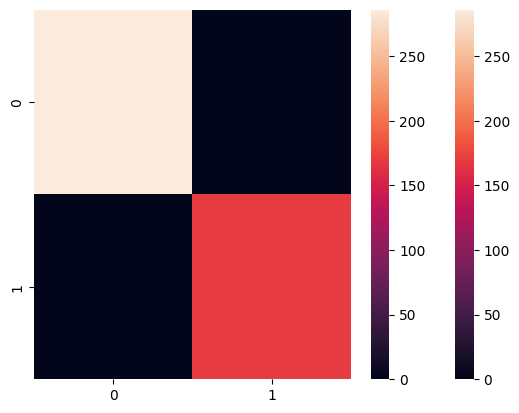

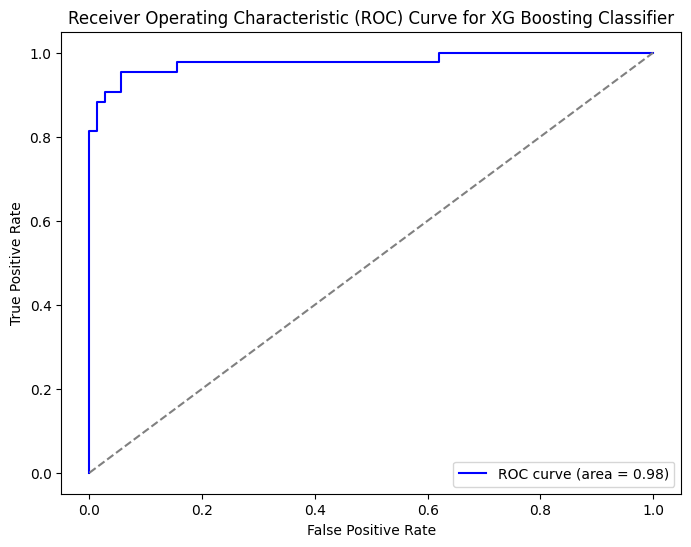


----- Fold ------
Accuracy Score of Training  : 1.0
Precision Score of Training : 1.0
F1 Score of Training        : 1.0
Recall Score of Training    : 1.0

Confusion Matrix :- 
 [[286   0]
 [  0 169]]

Accuracy Score of Testing  : 0.9824561403508771
Precision Score of Testing : 0.9767441860465116
F1 Score of Testing        : 0.9767441860465116
Recall Score of Testing    : 0.9767441860465116

Confusion Matrix :- 
 [[286   0]
 [  0 169]]


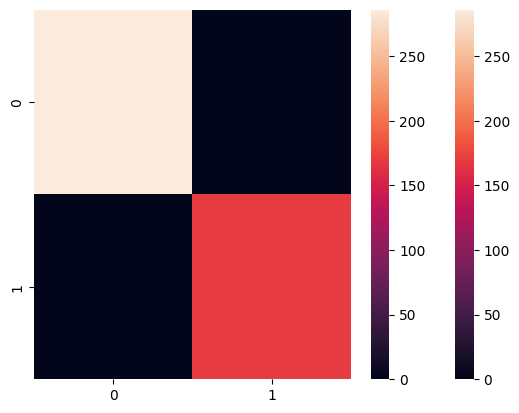

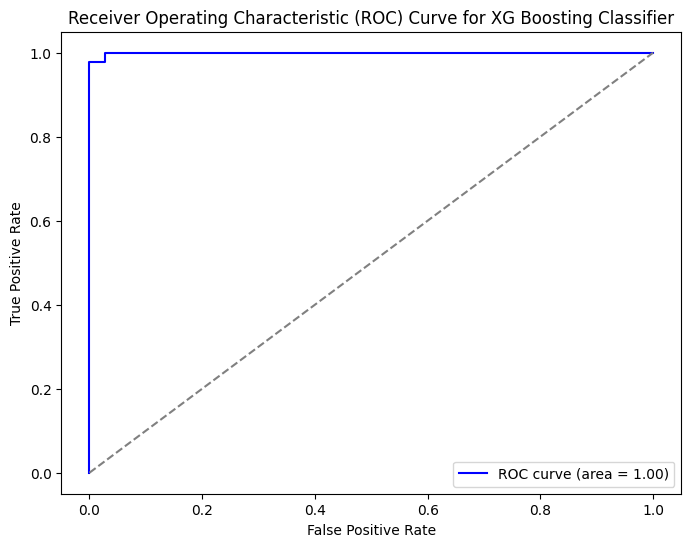


----- Fold ------
Accuracy Score of Training  : 1.0
Precision Score of Training : 1.0
F1 Score of Training        : 1.0
Recall Score of Training    : 1.0

Confusion Matrix :- 
 [[290   0]
 [  0 166]]

Accuracy Score of Testing  : 0.9734513274336283
Precision Score of Testing : 0.9777777777777777
F1 Score of Testing        : 0.967032967032967
Recall Score of Testing    : 0.9565217391304348

Confusion Matrix :- 
 [[290   0]
 [  0 166]]


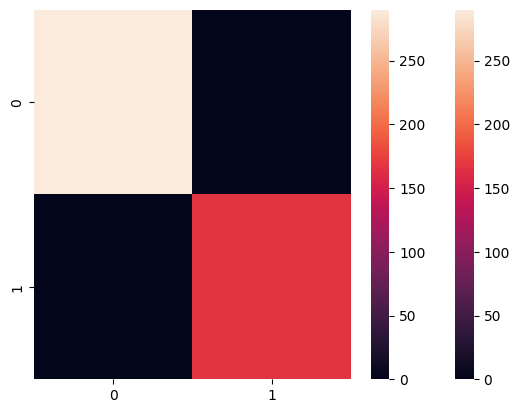

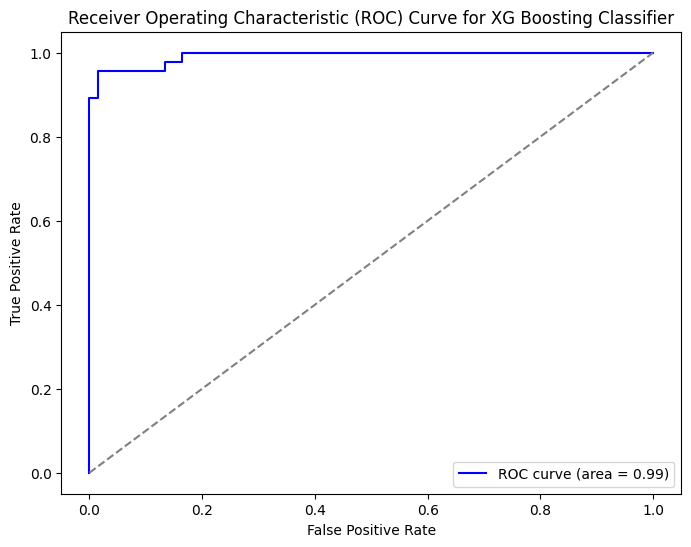

In [ ]:
accuracy = []
precision = []
f1 = []
recall = []
area = []

model = XGBClassifier(colsample_bytree = 0.6, gamma = 0, learning_rate = 0.2, max_depth = 3, n_estimators = 200, subsample = 0.6)
kf = KFold(n_splits=5,shuffle=True,random_state=42)

for train_index,test_index in kf.split(x):

  x_train,x_test = x_norm.iloc[train_index],x_norm.iloc[test_index]
  y_train,y_test = y.iloc[train_index],y.iloc[test_index]

  print("\n----- Fold ------")

  model.fit(x_train,y_train)
  y_pre_train = model.predict(x_train)
  con_train_model = confusion_matrix(y_train,y_pre_train)
  sns.heatmap(con_train_model)

  accuracy_model_train = accuracy_score(y_train,y_pre_train)
  precision_model_train = precision_score(y_train,y_pre_train)
  f1_model_train = f1_score(y_train,y_pre_train)
  recall_model_train = recall_score(y_train,y_pre_train)

  print("Accuracy Score of Training  :",accuracy_model_train)
  print("Precision Score of Training :",precision_model_train)
  print("F1 Score of Training        :",f1_model_train)
  print("Recall Score of Training    :",recall_model_train)
  print("\nConfusion Matrix :- \n",con_train_model)

  y_pre_test = model.predict(x_test)
  con_test_model = confusion_matrix(y_train,y_pre_train)
  sns.heatmap(con_test_model)

  accuracy_model_test = accuracy_score(y_test,y_pre_test)
  precision_model_test = precision_score(y_test,y_pre_test)
  f1_model_test = f1_score(y_test,y_pre_test)
  recall_model_test = recall_score(y_test,y_pre_test)

  accuracy.append(accuracy_model_test)
  precision.append(precision_model_test)
  f1.append(f1_model_test)
  recall.append(recall_model_test)

  print("\nAccuracy Score of Testing  :",accuracy_model_test)
  print("Precision Score of Testing :",precision_model_test)
  print("F1 Score of Testing        :",f1_model_test)
  print("Recall Score of Testing    :",recall_model_test)
  print("\nConfusion Matrix :- \n",con_test_model)

  y_probs_model = model.predict_proba(x_test)[:, 1]

  fpr_model, tpr_model, thresholds = roc_curve(y_test, y_probs_model)

  roc_auc_model = auc(fpr_model, tpr_model)

  area.append(roc_auc_model)

  plt.figure(figsize=(8, 6))
  plt.plot(fpr_model, tpr_model, color='b', label=f'ROC curve (area = {roc_auc_model:.2f})')
  plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for XG Boosting Classifier')
  plt.legend(loc='lower right')
  plt.show()

In [ ]:
df = pd.DataFrame({
    'KFold': list(range(1, 6)),
    'accuracy': accuracy,
    'precision': precision,
    'f1': f1,
    'recall': recall,
    'auc': area
})

mean_row = pd.DataFrame([{
    'KFold': 'Mean',
    'accuracy': np.mean(accuracy),
    'precision': np.mean(precision),
    'f1': np.mean(f1),
    'recall': np.mean(recall),
    'auc': np.mean(area)
}])

df = pd.concat([df, mean_row], ignore_index=True)


print("K Fold for XG Boosting Classifier:-\n")
df

K Fold for XG Boosting Classifier:-



,KFold,accuracy,precision,f1,recall,auc
0,1,0.973684,1.000000,0.963855,0.930233,0.993777
1,2,0.982456,0.972973,0.972973,0.972973,0.999298
2,3,0.938596,0.928571,0.917647,0.906977,0.977727
3,4,0.982456,0.976744,0.976744,0.976744,0.999345
4,5,0.973451,0.977778,0.967033,0.956522,0.992537
5,Mean,0.970129,0.971213,0.959651,0.948690,0.992537
